Ce notebook a pour objectif d’expliquer les décisions du modèle de Machine Learning.

Même si les modèles comme Random Forest sont performants, ils sont souvent considérés comme des “boîtes noires”.

L’objectif ici est donc de comprendre quelles variables influencent le plus les prédictions et comment chaque feature impacte le prix final.

 1. Chargement des données

Le dataset est chargé directement depuis la version stable (train.csv), utilisée dans les étapes précédentes du projet.

Cela garantit la cohérence entre les différentes analyses et modèles.

 2. Feature Engineering

Les mêmes variables créées précédemment sont utilisées :

TotalSF : surface totale de la maison

HouseAge : âge de la maison

QualityScore : score combinant qualité et condition générale

Ces features permettent une meilleure compréhension du marché immobilier.

 3. Sélection des variables

Les variables utilisées pour l’entraînement du modèle sont :

GrLivArea

OverallQual

GarageCars

TotalBsmtSF

YearBuilt

TotalSF

HouseAge

QualityScore

La variable cible reste :

SalePrice

 4. Préparation des données

Les données sont nettoyées avec suppression des valeurs manquantes, puis divisées en :

80% entraînement
20% test

Cela permet d’évaluer les explications sur des données non vues par le modèle.

 5. Entraînement du modèle

Un modèle Random Forest Regressor est entraîné avec 200 arbres.

Ce modèle est choisi car il offre un bon compromis entre performance et capacité d’interprétation via les importances des variables.

 6. Feature Importance

Une première méthode d’explicabilité est utilisée :

 Importance des variables

Le modèle calcule automatiquement l’importance de chaque feature.

Cela permet d’identifier les variables les plus influentes sur le prix des maisons.

 7. Explicabilité avancée avec SHAP

La bibliothèque SHAP (SHapley Additive exPlanations) est utilisée pour aller plus loin dans l’interprétation du modèle.

 SHAP Summary Plot

Ce graphique montre :

l’impact global de chaque variable

la direction de l’influence (augmentation ou diminution du prix)

 SHAP Force Plot

Une prédiction individuelle est analysée pour comprendre :

pourquoi le modèle a fait cette prédiction

quelles variables ont le plus influencé ce résultat

comment chaque feature contribue au prix final

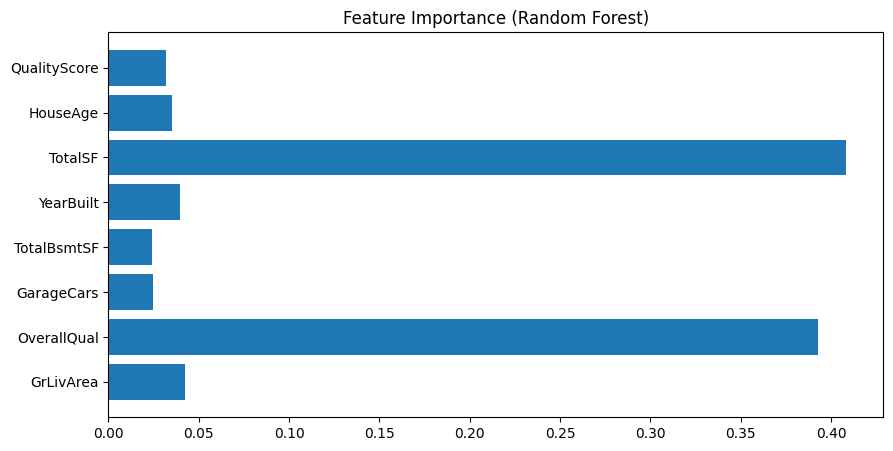

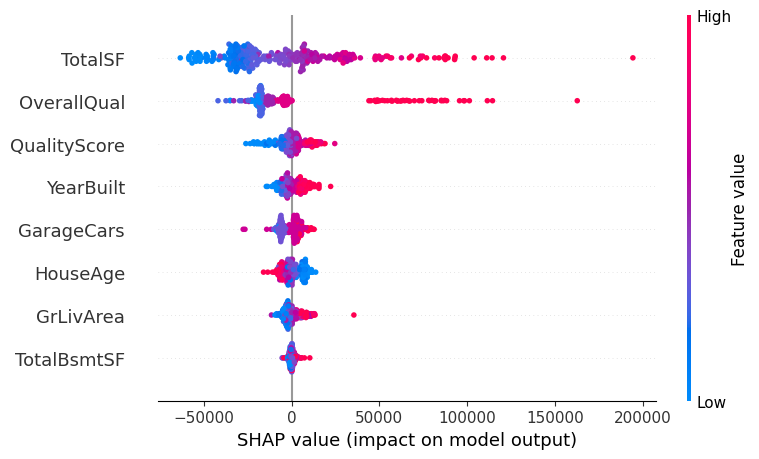

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

import shap

# ==============================
# LOAD DATA (STABLE)
# ==============================

df = pd.read_csv("data/raw/train.csv")

# ==============================
# FEATURE ENGINEERING
# ==============================

df["TotalSF"] = df["GrLivArea"] + df["TotalBsmtSF"]
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["QualityScore"] = df["OverallQual"] * df["OverallCond"]

# ==============================
# FEATURES
# ==============================

features = [
    "GrLivArea",
    "OverallQual",
    "GarageCars",
    "TotalBsmtSF",
    "YearBuilt",
    "TotalSF",
    "HouseAge",
    "QualityScore"
]

target = "SalePrice"

df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

# ==============================
# TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==============================
# MODEL
# ==============================

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

# ==============================
# FEATURE IMPORTANCE
# ==============================

importances = model.feature_importances_

plt.figure(figsize=(10,5))
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

# ==============================
# SHAP EXPLANATION
# ==============================

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# global importance
shap.summary_plot(shap_values, X_test)

# JS init (pour notebooks)
shap.initjs()

# explanation d'une ligne
i = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test.iloc[i]
)